In [1]:
# Import all the necessary modules
import os
import sys
import os, sys
# from .../research/notebooks -> go up two levels to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
import pandas_datareader as pdr
import math
import datetime as dt
from datetime import datetime, timezone
import itertools
import ast
import yfinance as yf
import seaborn as sn
import yaml
import requests
from pathlib import Path
from IPython.display import display, HTML
from strategy_signal.trend_following_signal import (
    apply_jupyter_fullscreen_css, get_trend_donchian_signal_for_portfolio_with_rolling_r_sqr_vol_of_vol
)
from portfolio.strategy_performance import (calculate_sharpe_ratio, calculate_calmar_ratio, calculate_CAGR, calculate_risk_and_performance_metrics,
                                          calculate_compounded_cumulative_returns, estimate_fee_per_trade, rolling_sharpe_ratio)
from utils import coinbase_utils as cn
from portfolio import strategy_performance as perf
from sizing import position_sizing_binary_utils as size_bin
from sizing import position_sizing_continuous_utils as size_cont
from strategy_signal import trend_following_signal as tf
%matplotlib inline

In [3]:
import importlib
importlib.reload(cn)
importlib.reload(perf)
importlib.reload(tf)
importlib.reload(size_bin)
importlib.reload(size_cont)

<module 'sizing.position_sizing_continuous_utils' from '/Users/adheerchauhan/git/trend_following/sizing/position_sizing_continuous_utils.py'>

In [5]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('Display.max_rows', None)
pd.set_option('Display.max_columns',None)
apply_jupyter_fullscreen_css()

## Kraken Connection

### OHLC Data

In [68]:
import requests

def kraken_public_ohlc(pair: str, interval_min: int = 240, since: int | None = None):
    url = "https://api.kraken.com/0/public/OHLC"
    params = {"pair": pair, "interval": interval_min}
    if since is not None:
        params["since"] = since
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

data = kraken_public_ohlc("BTC/USD", 240)
print(list(data.keys()))
print(data["error"])

['error', 'result']
[]


In [48]:
import pandas as pd

def kraken_ohlc_to_df(ohlc_json: dict) -> pd.DataFrame:
    """
    Convert Kraken OHLC JSON response (from /0/public/OHLC) into a pandas DataFrame.

    Output:
      - index: pandas datetime (UTC)
      - columns: open, high, low, close, vwap, volume, count
    """
    if ohlc_json.get("error"):
        raise RuntimeError(f"Kraken OHLC error: {ohlc_json['error']}")

    result = ohlc_json["result"]

    # Kraken uses a dynamic key for the pair in result, plus 'last'
    pair_key = next(k for k in result.keys() if k != "last")
    rows = result[pair_key]

    cols = ["time", "open", "high", "low", "close", "vwap", "volume", "count"]
    df = pd.DataFrame(rows, columns=cols)

    # Convert timestamp to pandas datetime (UTC)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()

    # Cast numeric columns (Kraken returns strings for most fields)
    numeric_cols = ["open", "high", "low", "close", "vwap", "volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["count"] = df["count"].astype(int)

    # Nice to keep the Kraken canonical pair key as metadata
    df.attrs["kraken_pair_key"] = pair_key
    df.attrs["last_cursor"] = result.get("last")

    return df


# Example usage:
data = kraken_public_ohlc("XBTUSD", 240)
df_btc = kraken_ohlc_to_df(data)
print(df_btc.head())
print(df_btc.tail())
print("pair_key:", df_btc.attrs["kraken_pair_key"], "last:", df_btc.attrs["last_cursor"])

                               open      high       low     close      vwap  \
time                                                                          
2025-10-27 12:00:00+00:00  115370.1  115370.1  114541.1  114940.0  114921.2   
2025-10-27 16:00:00+00:00  114940.1  115786.1  114791.9  114883.2  115389.8   
2025-10-27 20:00:00+00:00  114883.3  114883.3  113801.4  114153.0  114347.5   
2025-10-28 00:00:00+00:00  114153.1  114497.5  113593.2  113923.5  114014.3   
2025-10-28 04:00:00+00:00  113923.6  114273.4  113565.4  114273.4  113949.4   

                               volume  count  
time                                          
2025-10-27 12:00:00+00:00  219.494131   6778  
2025-10-27 16:00:00+00:00  195.420600   6668  
2025-10-27 20:00:00+00:00  181.587183   6250  
2025-10-28 00:00:00+00:00   87.820294   4902  
2025-10-28 04:00:00+00:00   59.914991   3416  
                              open     high      low    close     vwap  \
time                                       

In [117]:
df_btc.shape

(721, 7)

In [119]:
240*3

720

In [115]:
df_btc.head(20)

,open,high,low,close,vwap,volume,count
time,,,,,,,
2025-10-27 12:00:00+00:00,115370.1,115370.1,114541.1,114940.0,114921.2,219.494131,6778
2025-10-27 16:00:00+00:00,114940.1,115786.1,114791.9,114883.2,115389.8,195.420600,6668
2025-10-27 20:00:00+00:00,114883.3,114883.3,113801.4,114153.0,114347.5,181.587183,6250
2025-10-28 00:00:00+00:00,114153.1,114497.5,113593.2,113923.5,114014.3,87.820294,4902
2025-10-28 04:00:00+00:00,113923.6,114273.4,113565.4,114273.4,113949.4,59.914991,3416
2025-10-28 08:00:00+00:00,114273.4,114619.6,114135.0,114333.0,114476.9,105.508377,3317
2025-10-28 12:00:00+00:00,114333.0,116023.4,114160.0,114725.1,115065.7,424.472115,8141
2025-10-28 16:00:00+00:00,114725.1,115586.2,113597.0,113683.5,114622.7,356.721362,7934
2025-10-28 20:00:00+00:00,113683.6,113683.6,112278.2,112918.0,112875.6,394.934348,9871


In [52]:
df_btc.tail()

,open,high,low,close,vwap,volume,count
time,,,,,,,
2026-02-23 20:00:00+00:00,64282.8,64988.8,63888.0,64624.1,64583.5,737.762578,9957
2026-02-24 00:00:00+00:00,64624.1,64971.0,63123.6,63542.0,63749.3,833.687402,15705
2026-02-24 04:00:00+00:00,63542.1,63574.7,62679.6,63155.0,63105.6,398.168668,13162
2026-02-24 08:00:00+00:00,63160.0,63408.4,62929.5,63224.2,63195.6,194.928586,7085
2026-02-24 12:00:00+00:00,63224.2,63230.5,63118.7,63199.7,63154.3,13.960775,320


<Axes: xlabel='time'>

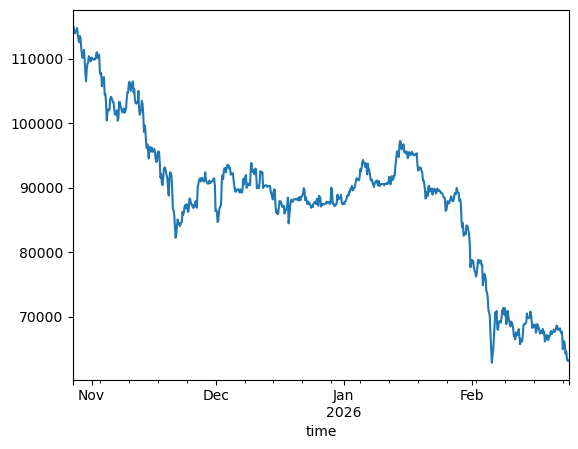

In [54]:
df_btc['close'].plot()

In [18]:
data = kraken_public_ohlc("XBTUSD", 240)

# Kraken uses a dynamic key for the pair inside "result"
print("Errors:", data["error"])
print("Result keys:", data["result"].keys())

# Pull out the OHLC array (first key that isn't 'last')
pair_key = next(k for k in data["result"].keys() if k != "last")
ohlc = data["result"][pair_key]

print("Pair key:", pair_key)
print("Num candles:", len(ohlc))
print("First candle:", ohlc[0])
print("Last candle:", ohlc[-1])

# 'last' is a server timestamp you can use for incremental pulling
print("Last cursor:", data["result"]["last"])

Errors: []
Result keys: dict_keys(['XXBTZUSD', 'last'])
Pair key: XXBTZUSD
Num candles: 721
First candle: [1761552000, '115562.9', '115562.9', '114846.5', '115370.1', '115297.2', '200.31445338', 4320]
Last candle: [1771920000, '63160.0', '63408.4', '62929.5', '63193.7', '63195.6', '194.63158398', 7003]
Last cursor: 1771905600


In [78]:
ohlc

[[1761552000,
  '115562.9',
  '115562.9',
  '114846.5',
  '115370.1',
  '115297.2',
  '200.31445338',
  4320],
 [1761566400,
  '115370.1',
  '115370.1',
  '114541.1',
  '114940.0',
  '114921.2',
  '219.49413055',
  6778],
 [1761580800,
  '114940.1',
  '115786.1',
  '114791.9',
  '114883.2',
  '115389.8',
  '195.42060049',
  6668],
 [1761595200,
  '114883.3',
  '114883.3',
  '113801.4',
  '114153.0',
  '114347.5',
  '181.58718335',
  6250],
 [1761609600,
  '114153.1',
  '114497.5',
  '113593.2',
  '113923.5',
  '114014.3',
  '87.82029355',
  4902],
 [1761624000,
  '113923.6',
  '114273.4',
  '113565.4',
  '114273.4',
  '113949.4',
  '59.91499133',
  3416],
 [1761638400,
  '114273.4',
  '114619.6',
  '114135.0',
  '114333.0',
  '114476.9',
  '105.50837703',
  3317],
 [1761652800,
  '114333.0',
  '116023.4',
  '114160.0',
  '114725.1',
  '115065.7',
  '424.47211467',
  8141],
 [1761667200,
  '114725.1',
  '115586.2',
  '113597.0',
  '113683.5',
  '114622.7',
  '356.72136187',
  7934],
 [1

In [74]:
data['result']#['XXBTZUSD']

{'BTC/USD': [[1761609600,
   '114153.1',
   '114497.5',
   '113593.2',
   '113923.5',
   '114014.3',
   '87.82029355',
   4902],
  [1761624000,
   '113923.6',
   '114273.4',
   '113565.4',
   '114273.4',
   '113949.4',
   '59.91499133',
   3416],
  [1761638400,
   '114273.4',
   '114619.6',
   '114135.0',
   '114333.0',
   '114476.9',
   '105.50837703',
   3317],
  [1761652800,
   '114333.0',
   '116023.4',
   '114160.0',
   '114725.1',
   '115065.7',
   '424.47211467',
   8141],
  [1761667200,
   '114725.1',
   '115586.2',
   '113597.0',
   '113683.5',
   '114622.7',
   '356.72136187',
   7934],
  [1761681600,
   '113683.6',
   '113683.6',
   '112278.2',
   '112918.0',
   '112875.6',
   '394.93434832',
   9871],
  [1761696000,
   '112918.0',
   '112918.0',
   '112118.5',
   '112550.0',
   '112507.1',
   '152.20341080',
   5050],
  [1761710400,
   '112550.0',
   '113511.0',
   '112549.9',
   '113511.0',
   '112964.6',
   '130.52635220',
   3637],
  [1761724800,
   '113511.0',
   '11360

## Private Requests using API Key & Secret

In [34]:
import time
import base64
import hashlib
import hmac
import urllib.parse
import requests

KRAKEN_API_URL = "https://api.kraken.com"
API_KEY = "LoBgNf94wTlWsuce8q36kfG9Ix1FKiksGMs/tiKgL6OH26kyYZ3heXgt"
API_SECRET = "gaoI8egmuFWfk5KqQ6xJewvgfhsh8/LaopxmPrHVV7ykoQh3L5TZ284Zn7Ooy98EOF7D6ultDprygWKu4TWjpg=="

def _kraken_api_sign(urlpath: str, data: dict, api_secret: str) -> str:
    """
    Creates API-Sign for Kraken private endpoints.
    api_secret is the *private key/secret* you saved (base64-encoded string).
    """
    postdata = urllib.parse.urlencode(data)
    encoded = (str(data["nonce"]) + postdata).encode()
    message = urlpath.encode() + hashlib.sha256(encoded).digest()
    mac = hmac.new(base64.b64decode(api_secret), message, hashlib.sha512)
    sigdigest = base64.b64encode(mac.digest())
    return sigdigest.decode()

def kraken_private_request(endpoint: str, api_key: str, api_secret: str, data: dict | None = None):
    """
    endpoint example: '/0/private/Balance'
    """
    if data is None:
        data = {}
    # Nonce must be strictly increasing; using ms timestamp is typical.
    data["nonce"] = int(time.time() * 1000)

    urlpath = endpoint
    url = KRAKEN_API_URL + urlpath

    headers = {
        "API-Key": api_key,
        "API-Sign": _kraken_api_sign(urlpath, data, api_secret),
    }

    r = requests.post(url, headers=headers, data=data, timeout=30)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken API error: {j['error']}")
    return j["result"]

# --- Examples ---

# 1) Balance
result = kraken_private_request("/0/private/Balance", API_KEY, API_SECRET)
print(result)

# 2) Open orders
result = kraken_private_request("/0/private/OpenOrders", API_KEY, API_SECRET, data={"trades": True})
print(result)

# 3) Closed orders (can be large; use 'start'/'end' as needed)
result = kraken_private_request("/0/private/ClosedOrders", API_KEY, API_SECRET, data={"trades": True})
print(result)

# 4) Ledger (fees, deposits/withdrawals; great for reconciliation)
result = kraken_private_request("/0/private/Ledgers", API_KEY, API_SECRET)
print(result)

{}
{'open': {}}
{'closed': {}, 'count': 0}
{'count': 0, 'ledger': {}}


## Get Tradable Pairs

In [123]:
import requests
import pandas as pd

def kraken_get_tradable_pairs() -> pd.DataFrame:
    url = "https://api.kraken.com/0/public/AssetPairs"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(j["error"])

    pairs = j["result"]  # dict keyed by REST pair id like "XXBTZUSD"
    rows = []
    for rest_pair, meta in pairs.items():
        rows.append({
            "rest_pair": rest_pair,
            "altname": meta.get("altname"),     # e.g., "XBTUSD"
            "wsname": meta.get("wsname"),       # e.g., "XBT/USD" if available
            "base": meta.get("base"),
            "quote": meta.get("quote"),
            "status": meta.get("status"),       # "online", etc.
            "pair_decimals": meta.get("pair_decimals"),
            "lot_decimals": meta.get("lot_decimals"),
            "ordermin": meta.get("ordermin"),
            "costmin": meta.get("costmin"),
        })
    df = pd.DataFrame(rows)

    # Common filter: keep only currently tradable markets
    df = df[df["status"] == "online"].reset_index(drop=True)
    return df

df_pairs = kraken_get_tradable_pairs()
print(df_pairs.head())
print("Online pairs:", len(df_pairs))

  rest_pair   altname     wsname   base quote  status  pair_decimals  \
0     0GEUR     0GEUR     0G/EUR     0G  ZEUR  online              3   
1     0GUSD     0GUSD     0G/USD     0G  ZUSD  online              3   
2  1INCHEUR  1INCHEUR  1INCH/EUR  1INCH  ZEUR  online              4   
3  1INCHUSD  1INCHUSD  1INCH/USD  1INCH  ZUSD  online              4   
4     2ZEUR     2ZEUR     2Z/EUR     2Z  ZEUR  online              5   

   lot_decimals ordermin costmin  
0             5        2    0.45  
1             5        2     0.5  
2             8       11    0.45  
3             8       11     0.5  
4             5       10    0.45  
Online pairs: 1436


In [197]:
df_pairs[df_pairs['quote'] == 'ZUSD'].head(200)

,rest_pair,altname,wsname,base,quote,status
1,0GUSD,0GUSD,0G/USD,0G,ZUSD,online
3,1INCHUSD,1INCHUSD,1INCH/USD,1INCH,ZUSD,online
5,2ZUSD,2ZUSD,2Z/USD,2Z,ZUSD,online
9,AAVEUSD,AAVEUSD,AAVE/USD,AAVE,ZUSD,online
12,ABUSD,ABUSD,AB/USD,AB,ZUSD,online
14,ACAUSD,ACAUSD,ACA/USD,ACA,ZUSD,online
16,ACHUSD,ACHUSD,ACH/USD,ACH,ZUSD,online
18,ACTUSD,ACTUSD,ACT/USD,ACT,ZUSD,online
20,ACUUSD,ACUUSD,ACU/USD,ACU,ZUSD,online
22,ACXUSD,ACXUSD,ACX/USD,ACX,ZUSD,online


In [131]:
len(df_pairs[df_pairs['quote'] == 'ZUSD'].wsname.unique())

624

In [204]:
df_pairs.quote.unique()

array(['ZEUR', 'ZUSD', 'XETH', 'ZGBP', 'XXBT', 'ZAUD', 'USDC', 'USDT',
       'ZJPY', 'CHF', 'DAI', 'EURC', 'EUROP', 'FIDD', 'PYUSD', 'USD1',
       'ZCAD', 'SOL', 'AUSD', 'USDD', 'RLUSD', 'USDQ', 'USDR'],
      dtype=object)

## Create Tradable List of Coins

### Layer A Filter

In [206]:
## Removing Non-Crypto FX Pairs, Stablecoins, cash-like tokens and synthetic/wrapped/staked-derivative style instruments
remove_list = ['AUD/USD', 'EUR/USD', 'GBP/USD', 'USDC/USD', 'USDT/USD', 'DAI/USD', 'USDD/USD', 'USDE/USD', 'USDR/USD', 'USDS/USD', 'USD1/USD', 'USDG/USD', 'USDQ/USD',
               'USDUC/USD', 'PYUSD/USD', 'RLUSD/USD', 'AUSD/USD', 'AUDX/USD', 'EURC/USD', 'EUROP/USD', 'EURQ/USD', 'EURR/USD', 'TGBP/USD', 'BRL1/USD', 'CASH/USD',
               'WBTC/USD', 'TBTC/USD', 'PAXG/USD', 'XAUT/USD', 'CMETH/USD', 'METH/USD', 'LSETH/USD', 'JITOSOL/USD', 'LSSOL/USD', 'LSSOL/USD', 'MSOL/USD', 'MXNB/USD']
quote_list = ['ZUSD']

In [210]:
df_pairs_layer_a_filt_zusd = df_pairs[(~df_pairs.wsname.isin(remove_list)) & (df_pairs['quote'].isin(quote_list))].reset_index(drop=True)

In [212]:
print(df_pairs_layer_a_filt_zusd.shape)
df_pairs_layer_a_filt_zusd

(603, 6)


,rest_pair,altname,wsname,base,quote,status
0,0GUSD,0GUSD,0G/USD,0G,ZUSD,online
1,1INCHUSD,1INCHUSD,1INCH/USD,1INCH,ZUSD,online
2,2ZUSD,2ZUSD,2Z/USD,2Z,ZUSD,online
3,AAVEUSD,AAVEUSD,AAVE/USD,AAVE,ZUSD,online
4,ABUSD,ABUSD,AB/USD,AB,ZUSD,online
5,ACAUSD,ACAUSD,ACA/USD,ACA,ZUSD,online
6,ACHUSD,ACHUSD,ACH/USD,ACH,ZUSD,online
7,ACTUSD,ACTUSD,ACT/USD,ACT,ZUSD,online
8,ACUUSD,ACUUSD,ACU/USD,ACU,ZUSD,online
9,ACXUSD,ACXUSD,ACX/USD,ACX,ZUSD,online


### Layer B (Liquidity Metrics) & Layer C (Stability) Screen

In [405]:
"""
Kraken Universe Construction: Layer A + Layer B + Layer C
========================================================

Goal:
- Build a tradable universe for a long-only, spot strategy on Kraken
- Quote currency: ZUSD (Kraken's USD)
- Use Kraken public APIs only (no keys needed)
- Layer A: hard excludes (FX, stables vs USD, synthetics/wrapped/staked, tokenized gold, etc.)
- Layer B: liquidity gate using point-in-time ADV proxy from OHLC (volume * vwap)
          implemented as "Top-N by ADV with an ADV floor" (more robust than fixed threshold)
- Layer C: stability / hysteresis:
          enter after 2 consecutive Layer-B passes
          exit after 2 consecutive Layer-B fails (1 grace period)

Notes:
- Kraken /0/public/OHLC returns up to ~720 candles. For 4h bars that's ~120 days,
  which is enough for 30–60 day ADV liquidity gating.
- For >120 days of 4h history you'll need Kraken downloadable datasets or trades aggregation
  (separate step; not needed for Layer A/B/C gating).

Run this file top-to-bottom in a notebook/script.

"""

from __future__ import annotations

import math
import time
import requests
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Optional, Iterable


# =========================
# 0) Config
# =========================
KRAKEN_REST = "https://api.kraken.com"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "kraken-universe-research/1.0"})


@dataclass(frozen=True)
class UniverseConfig:
    # Quote currency to focus on (Kraken uses ZUSD for USD)
    quote_ccy: str = "ZUSD"

    # OHLC interval: 4h bars for your setup
    interval_min: int = 240

    # Liquidity metric window (days)
    adv_window_days: int = 60

    # Rolling ADV min fraction (relaxed so newer pairs can qualify)
    adv_min_frac: float = 0.35  # 35% of window required; increase once stable

    # Universe selection: choose top N by ADV each eval date, after applying floor
    top_n: int = 200
    adv_floor_usd: float = 200_000.0  # avoid true dust; tune upward later

    # Evaluation cadence for universe membership panel
    eval_freq: str = "MS"  # monthly start. Try "2W" for bi-weekly.

    # Politeness: pause between OHLC calls (reduce to go faster; increase if throttled)
    sleep_between_ohlc_calls_s: float = 0.05


CFG = UniverseConfig()


# =========================
# 1) Kraken API helpers (public)
# =========================
def _kraken_get(path: str, params: Optional[dict] = None, timeout: int = 30) -> dict:
    url = f"{KRAKEN_REST}{path}"
    r = SESSION.get(url, params=params or {}, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken error for {path}: {j['error']}")
    return j["result"]


def kraken_assetpairs_df() -> pd.DataFrame:
    """
    Returns a DataFrame of all pairs with fields:
      - pair (REST pair key): e.g. XXBTZUSD  <-- USE THIS for OHLC/Depth API calls
      - altname: e.g. XBTUSD
      - wsname: e.g. XBT/USD (best for display)
      - base/quote: Kraken internal asset codes
      - status: online/offline
    """
    result = _kraken_get("/0/public/AssetPairs")
    rows = []
    for rest_pair, meta in result.items():
        rows.append({
            "pair": rest_pair,               # <- canonical for API calls
            "altname": meta.get("altname"),
            "wsname": meta.get("wsname"),
            "base": meta.get("base"),
            "quote": meta.get("quote"),
            "status": meta.get("status"),
        })
    return pd.DataFrame(rows)


def kraken_ohlc_df(pair: str, interval_min: int = 240) -> pd.DataFrame:
    """
    Fetch OHLC for a Kraken pair. Use REST pair key (e.g. XXBTZUSD).
    Returns DataFrame indexed by UTC timestamp with:
      open, high, low, close, vwap, volume, count
    """
    params = {"pair": pair, "interval": interval_min}
    result = _kraken_get("/0/public/OHLC", params=params)

    # result contains dynamic key + 'last'
    pair_key = next(k for k in result.keys() if k != "last")
    rows = result[pair_key]
    if not rows:
        return pd.DataFrame()

    cols = ["time", "open", "high", "low", "close", "vwap", "volume", "count"]
    df = pd.DataFrame(rows, columns=cols)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()
    df[["open", "high", "low", "close", "vwap", "volume"]] = df[["open", "high", "low", "close", "vwap", "volume"]].astype(float)
    df["count"] = df["count"].astype(int)
    return df


# =========================
# 2) Layer A: Hard excludes
# =========================
def layer_a_is_excluded(wsname: Optional[str]) -> bool:
    """
    Layer A exclusion rule based on the wsname (human-readable) like 'XBT/USD'.
    We exclude:
      - FX pairs (AUD/USD, EUR/USD, GBP/USD)
      - Stablecoins/fiat-pegged tokens vs USD (USDC/USD, USDT/USD, etc.)
      - Tokenized gold (PAXG/USD, XAUT/USD)
      - Wrapped/staked/synthetic derivatives (WBTC/USD, TBTC/USD, staked ETH/SOL variants)
      - Other 'cash-like' tokens (CASH/USD, etc.)

    This is intentionally conservative to keep the initial universe clean.
    """
    if not wsname or not isinstance(wsname, str):
        return True

    w = wsname.strip().upper()

    # FX
    fx_excludes = {"AUD/USD", "EUR/USD", "GBP/USD"}

    # Stablecoins / fiat-pegs vs USD (extend as you discover new ones)
    stable_excludes = {
        "USDC/USD", "USDT/USD", "DAI/USD", "PYUSD/USD", "RLUSD/USD",
        "USDD/USD", "USDE/USD", "USDR/USD", "USDS/USD",
        "USD1/USD", "USDG/USD", "USDQ/USD", "USDUC/USD",
        "AUSD/USD", "AUDX/USD", "EURC/USD", "EUROP/USD", "EURQ/USD", "EURR/USD",
        "TGBP/USD", "BRL1/USD",
        "CASH/USD", "MXNB/USD",
    }

    # Tokenized commodities
    commodity_excludes = {"PAXG/USD", "XAUT/USD"}

    # Wrapped / synthetic / staked derivatives
    synthetic_excludes = {
        "WBTC/USD", "TBTC/USD",
        "METH/USD", "LSETH/USD", "CMETH/USD",
        "JITOSOL/USD", "LSSOL/USD", "MSOL/USD",
    }

    return (w in fx_excludes) or (w in stable_excludes) or (w in commodity_excludes) or (w in synthetic_excludes)


def apply_layer_a(df_pairs: pd.DataFrame, quote_ccy: str) -> pd.DataFrame:
    """
    Filters to:
      - status == online
      - quote == quote_ccy (ZUSD)
      - wsname exists
      - NOT excluded by Layer A rule
    """
    df = df_pairs.copy()
    df = df[(df["status"] == "online") & (df["quote"] == quote_ccy)].copy()
    df = df[df["wsname"].notna()].copy()

    df["layer_a_excluded"] = df["wsname"].apply(layer_a_is_excluded)
    df = df[~df["layer_a_excluded"]].copy()

    # Keep only the fields we need downstream
    df = df[["pair", "wsname", "altname", "base", "quote", "status"]].reset_index(drop=True)
    return df


# =========================
# 3) Layer B: Liquidity ranking by ADV
# =========================
def compute_daily_adv_usd(df_ohlc: pd.DataFrame) -> pd.Series:
    """
    ADV USD proxy = sum over day of (volume * vwap).
    OHLC volume is base-asset volume; VWAP in quote (USD) => notional proxy.
    """
    notional = df_ohlc["volume"] * df_ohlc["vwap"]
    return notional.resample("1D").sum()


def rolling_adv_usd(df_ohlc: pd.DataFrame, window_days: int, min_frac: float) -> pd.Series:
    daily_adv = compute_daily_adv_usd(df_ohlc)
    min_periods = max(10, math.ceil(window_days * min_frac))
    return daily_adv.rolling(window_days, min_periods=min_periods).mean()


def build_layer_b_panel_topN(
    df_universe_a: pd.DataFrame,
    cfg: UniverseConfig
) -> pd.DataFrame:
    """
    Build a point-in-time panel over evaluation dates with:
      - adv_usd (rolling)
      - pass_layer_b (top N by adv after applying floor)

    Output columns:
      date, pair, wsname, adv_usd, adv_floor_usd, top_n, pass_layer_b
    """
    pairs = df_universe_a["pair"].tolist()
    ws_lookup = df_universe_a.set_index("pair")["wsname"].to_dict()

    # Pull OHLC for each pair, compute rolling ADV series
    adv_by_pair: Dict[str, pd.Series] = {}
    ohlc_index_union = pd.Index([])

    for i, p in enumerate(pairs, 1):
        try:
            df_ohlc = kraken_ohlc_df(p, interval_min=cfg.interval_min)
            if df_ohlc.empty:
                adv_by_pair[p] = pd.Series(dtype=float)
            else:
                ohlc_index_union = ohlc_index_union.union(df_ohlc.index)
                adv_by_pair[p] = rolling_adv_usd(df_ohlc, cfg.adv_window_days, cfg.adv_min_frac)
        except Exception:
            adv_by_pair[p] = pd.Series(dtype=float)

        if cfg.sleep_between_ohlc_calls_s > 0:
            time.sleep(cfg.sleep_between_ohlc_calls_s)

    if len(ohlc_index_union) == 0:
        raise RuntimeError("No OHLC data retrieved for any pairs. Check Kraken connectivity and pair identifiers.")

    # Evaluation dates: across available window. If you want to skip early period
    # where very few series exist, that's OK — layer C stability will handle this.
    start = ohlc_index_union.min().floor("D")
    end = ohlc_index_union.max().floor("D")
    eval_dates = pd.date_range(start=start, end=end, freq=cfg.eval_freq, tz="UTC").floor("D")

    rows = []
    for d in eval_dates:
        snapshot = []
        for p, s in adv_by_pair.items():
            if s is None or len(s) == 0:
                continue
            s2 = s.loc[:d].dropna()
            if len(s2) == 0:
                continue
            snapshot.append((p, float(s2.iloc[-1])))

        snap_df = pd.DataFrame(snapshot, columns=["pair", "adv_usd"])
        if snap_df.empty:
            continue

        # Apply floor then rank
        snap_df = snap_df[snap_df["adv_usd"] >= cfg.adv_floor_usd].copy()
        snap_df = snap_df.sort_values("adv_usd", ascending=False)

        top_pairs = set(snap_df.head(cfg.top_n)["pair"].tolist())

        for _, r in snap_df.iterrows():
            p = r["pair"]
            rows.append({
                "date": d,
                "pair": p,
                "wsname": ws_lookup.get(p, p),
                "adv_usd": r["adv_usd"],
                "adv_floor_usd": float(cfg.adv_floor_usd),
                "top_n": int(cfg.top_n),
                "pass_layer_b": (p in top_pairs),
            })

    panel_b = pd.DataFrame(rows)
    if panel_b.empty:
        raise RuntimeError(
            "Layer B panel is empty. Most likely adv_floor_usd is too high, "
            "or OHLC data retrieval failed for most pairs."
        )

    panel_b = panel_b.sort_values(["date", "adv_usd"], ascending=[True, False]).reset_index(drop=True)
    return panel_b


# =========================
# 4) Layer C: Stability / hysteresis
# =========================
def apply_layer_c_stability(panel_b: pd.DataFrame) -> pd.DataFrame:
    """
    Stability rules:
      - enter after 2 consecutive Layer-B passes
      - exit after 2 consecutive Layer-B fails (1 grace)
    """
    panel = panel_b.copy()
    panel["date"] = pd.to_datetime(panel["date"], utc=True).dt.floor("D")

    out = []
    for pair, g in panel.groupby("pair"):
        g = g.sort_values("date").copy()
        passes = g["pass_layer_b"].astype(bool).tolist()

        active = False
        pass_streak = 0
        fail_streak = 0
        active_list = []

        for ok in passes:
            if ok:
                pass_streak += 1
                fail_streak = 0
            else:
                fail_streak += 1
                pass_streak = 0

            if (not active) and pass_streak >= 2:
                active = True
            if active and fail_streak >= 2:
                active = False

            active_list.append(active)

        g["active_universe"] = active_list
        out.append(g)

    panel_c = pd.concat(out, ignore_index=True).sort_values(["date", "pair"]).reset_index(drop=True)
    return panel_c


def universe_list_by_date(panel_c: pd.DataFrame) -> Dict[pd.Timestamp, List[str]]:
    """
    Returns dict: date -> list of wsname tickers (e.g., 'XBT/USD') active in universe.
    """
    out: Dict[pd.Timestamp, List[str]] = {}
    for d, g in panel_c.groupby("date"):
        out[d] = sorted(g.loc[g["active_universe"], "wsname"].tolist())
    return out


# =========================
# 5) Run pipeline
# =========================
if __name__ == "__main__":
    # A) Pull pairs
    df_pairs_all = kraken_assetpairs_df()

    # B) Layer A filter
    df_universe_a = apply_layer_a(df_pairs_all, quote_ccy=CFG.quote_ccy)
    print(f"Layer A universe size (after hard excludes): {len(df_universe_a)}")

    # C) Layer B liquidity ranking (Top N by ADV)
    panel_b = build_layer_b_panel_topN(df_universe_a, CFG)
    last_date_b = panel_b["date"].max()
    snap_b = panel_b[panel_b["date"] == last_date_b]
    print(f"Layer B latest eval date: {last_date_b} | "
          f"pairs w/ ADV computed (>=floor): {snap_b['pair'].nunique()} | "
          f"pass_layer_b (top N): {int(snap_b['pass_layer_b'].sum())}")

    # D) Layer C stability
    panel_c = apply_layer_c_stability(panel_b)

    # E) Final universe at latest eval date
    uni_by_date = universe_list_by_date(panel_c)
    last_date = sorted(uni_by_date.keys())[-1]
    universe_latest = uni_by_date[last_date]

    print(f"Latest eval date: {last_date} Universe size: {len(universe_latest)}")
    print("Pairs:", universe_latest[:40], "..." if len(universe_latest) > 40 else "")

    # Optional: export to disk
    # panel_b.to_parquet("kraken_panel_b.parquet", index=False)
    # panel_c.to_parquet("kraken_panel_c.parquet", index=False)
    # pd.Series({k: len(v) for k,v in uni_by_date.items()}).to_csv("universe_sizes.csv")

Layer A universe size (after hard excludes): 588
Layer B latest eval date: 2026-02-01 00:00:00+00:00 | pairs w/ ADV computed (>=floor): 93 | pass_layer_b (top N): 93
Latest eval date: 2026-02-01 00:00:00+00:00 Universe size: 84
Pairs: ['0G/USD', 'AAVE/USD', 'ADA/USD', 'AERO/USD', 'ALGO/USD', 'APT/USD', 'ARB/USD', 'ASTER/USD', 'ATOM/USD', 'AVAX/USD', 'AVNT/USD', 'BAT/USD', 'BCH/USD', 'BNB/USD', 'BONK/USD', 'CC/USD', 'CRV/USD', 'DASH/USD', 'DOG/USD', 'DOT/USD', 'EIGEN/USD', 'ENA/USD', 'ETH/USD', 'FARTCOIN/USD', 'FET/USD', 'FIL/USD', 'FLR/USD', 'H/USD', 'HBAR/USD', 'ICP/USD', 'INJ/USD', 'IP/USD', 'KAS/USD', 'KTA/USD', 'LINK/USD', 'LTC/USD', 'LUNA/USD', 'MNT/USD', 'MON/USD', 'MOODENG/USD'] ...


## Final Universe Sanity Check

In [422]:
import time
import math
import requests
import pandas as pd
import matplotlib.pyplot as plt

KRAKEN_REST = "https://api.kraken.com"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "kraken-universe-sanity/1.0"})


# -------------------------
# Kraken helpers
# -------------------------
def _kraken_get(path: str, params=None, timeout: int = 30) -> dict:
    url = f"{KRAKEN_REST}{path}"
    r = SESSION.get(url, params=params or {}, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if j.get("error"):
        raise RuntimeError(f"Kraken error {path}: {j['error']}")
    return j["result"]


def kraken_best_spread_bps(pair_rest: str, depth: int = 1) -> float:
    """
    One-shot spread bps using /0/public/Depth best bid/ask.
    Spread (bps) = (ask - bid) / mid * 1e4
    """
    result = _kraken_get("/0/public/Depth", params={"pair": pair_rest, "count": depth})
    pair_key = next(iter(result.keys()))
    book = result[pair_key]
    asks = book.get("asks", [])
    bids = book.get("bids", [])
    if not asks or not bids:
        return float("nan")

    best_ask = float(asks[0][0])
    best_bid = float(bids[0][0])
    mid = 0.5 * (best_ask + best_bid)
    if mid <= 0:
        return float("nan")

    return (best_ask - best_bid) / mid * 1e4


# -------------------------
# Inputs: choose your eval date
# -------------------------
def get_active_universe_for_date(panel_c: pd.DataFrame, eval_date: pd.Timestamp) -> pd.DataFrame:
    """
    Returns DataFrame with columns: pair, wsname for active_universe==True on eval_date
    """
    d = pd.to_datetime(eval_date, utc=True).floor("D")
    pc = panel_c.copy()
    pc["date"] = pd.to_datetime(pc["date"], utc=True).dt.floor("D")
    snap = pc[(pc["date"] == d) & (pc["active_universe"] == True)].copy()
    # Ensure wsname exists
    if "wsname" not in snap.columns:
        raise ValueError("panel_c must include wsname. If not, merge from df_universe_a.")
    return snap[["pair", "wsname"]].drop_duplicates().reset_index(drop=True)


def get_adv_snapshot(panel_b: pd.DataFrame, eval_date: pd.Timestamp) -> pd.DataFrame:
    """
    Returns ADV snapshot for eval_date for all pairs present in panel_b on that date.
    """
    d = pd.to_datetime(eval_date, utc=True).floor("D")
    pb = panel_b.copy()
    pb["date"] = pd.to_datetime(pb["date"], utc=True).dt.floor("D")
    snap = pb[pb["date"] == d].copy()
    return snap


# -------------------------
# A) ADV distribution + tails
# -------------------------
def adv_diagnostics(adv_active: pd.DataFrame, adv_floor_usd: float | None = None):
    """
    adv_active columns: wsname, adv_usd
    """
    df = adv_active.copy().sort_values("adv_usd", ascending=False).reset_index(drop=True)

    # Summary stats
    stats = df["adv_usd"].describe(percentiles=[0.05,0.10,0.25,0.5,0.75,0.9,0.95]).to_frame("adv_usd")
    print("\n=== ADV Summary (active universe) ===")
    print(stats)

    # Bottom 20 names
    print("\n=== Bottom 20 by ADV (active universe) ===")
    print(df.sort_values("adv_usd").head(20)[["wsname","adv_usd"]].to_string(index=False))

    if adv_floor_usd is not None:
        print(f"\nADV floor used in Layer B: {adv_floor_usd:,.0f} USD/day")
        near_floor = df[df["adv_usd"] <= adv_floor_usd * 1.5]
        print(f"Names within 1.5x of floor: {len(near_floor)}/{len(df)}")

    # Plot histogram (log scale is usually more informative)
    plt.figure()
    plt.hist(df["adv_usd"].values, bins=30)
    plt.xlabel("ADV (USD/day)")
    plt.ylabel("Count")
    plt.title("ADV Distribution (Active Universe)")
    plt.show()

    plt.figure()
    plt.hist((df["adv_usd"].values + 1.0), bins=30)
    plt.yscale("linear")
    plt.xscale("log")
    plt.xlabel("ADV (USD/day) [log scale]")
    plt.ylabel("Count")
    plt.title("ADV Distribution (Active Universe) [log-x]")
    plt.show()

    return df


# -------------------------
# B) Concentration (Top 10 ADV share)
# -------------------------
def concentration_diagnostics(adv_active_sorted: pd.DataFrame, top_k: int = 10):
    df = adv_active_sorted.copy().sort_values("adv_usd", ascending=False).reset_index(drop=True)
    total_adv = df["adv_usd"].sum()
    top_adv = df.head(top_k)["adv_usd"].sum()
    share = top_adv / total_adv if total_adv > 0 else float("nan")

    print(f"\n=== Concentration ===")
    print(f"Total ADV (active): {total_adv:,.0f} USD/day")
    print(f"Top {top_k} ADV: {top_adv:,.0f} USD/day")
    print(f"Top {top_k} share: {share:.2%}")

    print(f"\nTop {top_k} names:")
    print(df.head(top_k)[["wsname","adv_usd"]].to_string(index=False))

    return share


# -------------------------
# C) Spread sampling (hourly snapshots for 1–2 weeks)
# -------------------------
def sample_spreads_hourly(
    pairs: pd.DataFrame,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
    freq: str = "1H",
    sleep_s: float = 0.05,
) -> pd.DataFrame:
    """
    pairs: DataFrame with columns pair (rest_pair), wsname
    Returns long DataFrame: time, pair, wsname, spread_bps
    """
    start_utc = pd.to_datetime(start_utc, utc=True)
    end_utc = pd.to_datetime(end_utc, utc=True)
    times = pd.date_range(start=start_utc, end=end_utc, freq=freq, tz="UTC")

    rows = []
    for ts in times:
        for _, r in pairs.iterrows():
            p = r["pair"]
            w = r["wsname"]
            try:
                s = kraken_best_spread_bps(p)
            except Exception:
                s = float("nan")
            rows.append({"time": ts, "pair": p, "wsname": w, "spread_bps": s})
            if sleep_s > 0:
                time.sleep(sleep_s)

    return pd.DataFrame(rows)


def spread_diagnostics(spread_samples: pd.DataFrame) -> pd.DataFrame:
    """
    Returns per-pair spread median/p90 and prints worst offenders.
    """
    df = spread_samples.dropna(subset=["spread_bps"]).copy()
    if df.empty:
        raise RuntimeError("No spread samples collected (all NaN).")

    g = df.groupby("wsname")["spread_bps"]
    out = pd.DataFrame({
        "spread_median_bps": g.median(),
        "spread_p90_bps": g.quantile(0.9),
        "n_samples": g.size(),
    }).reset_index().sort_values(["spread_median_bps"], ascending=False)

    print("\n=== Spread Summary (bps) ===")
    print(out.head(20).to_string(index=False))

    return out


# -------------------------
# Main runner: A/B/C sanity checks
# -------------------------
def run_universe_sanity_checks(
    panel_b: pd.DataFrame,
    panel_c: pd.DataFrame,
    eval_date: str | pd.Timestamp,
    do_spreads: bool = True,
    spread_days: int = 14,
    spread_freq: str = "1H",
    spread_sleep_s: float = 0.05,
):
    eval_date = pd.to_datetime(eval_date, utc=True).floor("D")

    # Active universe list (Layer C)
    active_pairs = get_active_universe_for_date(panel_c, eval_date)

    # ADV snapshot (Layer B) for that date
    adv_snap = get_adv_snapshot(panel_b, eval_date)

    # Merge ADV onto active set
    adv_active = active_pairs.merge(
        adv_snap[["pair","wsname","adv_usd","adv_floor_usd"]].drop_duplicates(),
        on=["pair","wsname"],
        how="left"
    )

    # A) ADV diagnostics
    adv_floor = float(adv_snap["adv_floor_usd"].dropna().iloc[0]) if "adv_floor_usd" in adv_snap.columns and adv_snap["adv_floor_usd"].notna().any() else None
    adv_sorted = adv_diagnostics(adv_active[["wsname","adv_usd"]].dropna(), adv_floor_usd=adv_floor)

    # B) concentration diagnostics
    top10_share = concentration_diagnostics(adv_sorted, top_k=10)

    # C) spread sampling (optional but recommended)
    spread_summary_df = None
    if do_spreads:
        # end_utc = pd.Timestamp.utcnow().tz_localize("UTC").floor("H")
        now = pd.Timestamp.utcnow()
        end_utc = (now.tz_convert("UTC") if now.tzinfo is not None else now.tz_localize("UTC")).floor("H")
        start_utc = end_utc - pd.Timedelta(days=spread_days)

        # sample only active universe pairs
        samples = sample_spreads_hourly(
            active_pairs,
            start_utc=start_utc,
            end_utc=end_utc,
            freq=spread_freq,
            sleep_s=spread_sleep_s
        )
        spread_summary_df = spread_diagnostics(samples)

        # Join ADV and spread to identify bad names (low ADV, high spread)
        joined = adv_active.merge(spread_summary_df, on="wsname", how="left")
        joined["liquidity_badness"] = joined["spread_median_bps"] / (joined["adv_usd"] + 1.0) * 1e9  # arbitrary scaling
        print("\n=== Worst by (High Spread / Low ADV) heuristic ===")
        print(joined.sort_values("liquidity_badness", ascending=False).head(25)[
            ["wsname","adv_usd","spread_median_bps","spread_p90_bps","n_samples"]
        ].to_string(index=False))

    return {
        "eval_date": eval_date,
        "n_active": len(active_pairs),
        "top10_adv_share": top10_share,
        "adv_active": adv_active,
        "spread_summary": spread_summary_df,
    }


=== ADV Summary (active universe) ===
            adv_usd
count  8.400000e+01
mean   5.327921e+06
std    2.014090e+07
min    2.006554e+05
5%     2.392088e+05
10%    2.609211e+05
25%    3.135513e+05
50%    6.965436e+05
75%    1.581834e+06
90%    6.099929e+06
95%    1.606791e+07
max    1.589754e+08

=== Bottom 20 by ADV (active universe) ===
     wsname       adv_usd
  EIGEN/USD 200655.393477
    OOB/USD 202339.496213
   PNUT/USD 210976.821500
    INJ/USD 231910.512711
    MNT/USD 236277.517217
    ARB/USD 255819.543114
    DOG/USD 256259.141306
   STBL/USD 256274.678259
    XTZ/USD 258892.180724
   ZBCN/USD 265655.096066
   AVNT/USD 267636.043151
MOODENG/USD 268294.696759
    APT/USD 269853.188708
     OP/USD 270319.998279
     IP/USD 278217.193260
  TRUMP/USD 284302.166885
    BAT/USD 284534.318610
   STRK/USD 285956.909313
    KTA/USD 297510.537802
   AERO/USD 306743.902176

ADV floor used in Layer B: 200,000 USD/day
Names within 1.5x of floor: 19/84


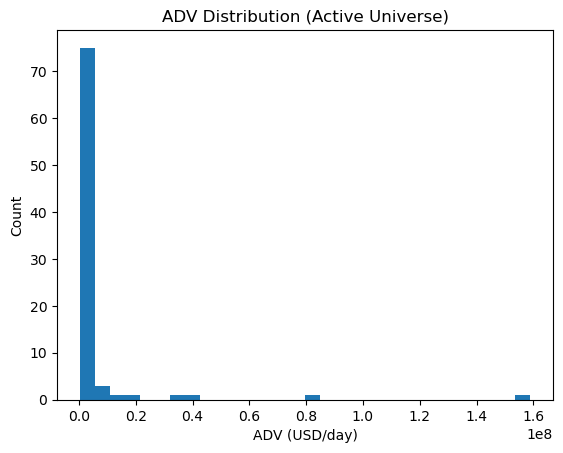

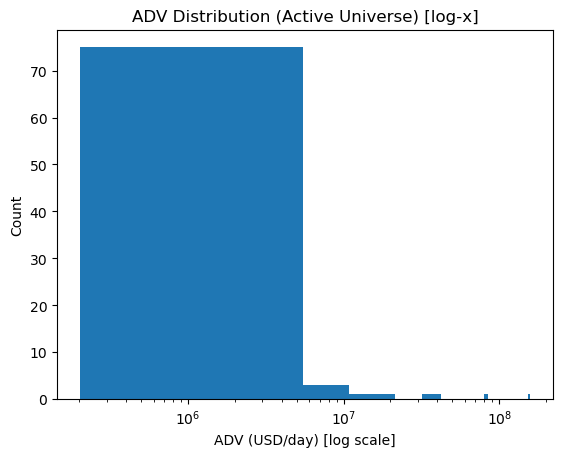


=== Concentration ===
Total ADV (active): 447,545,385 USD/day
Top 10 ADV: 377,085,210 USD/day
Top 10 share: 84.26%

Top 10 names:
      wsname      adv_usd
     XBT/USD 1.589754e+08
     ETH/USD 8.338298e+07
     SOL/USD 4.230568e+07
     XRP/USD 3.575284e+07
     ZEC/USD 1.668465e+07
     SUI/USD 1.257309e+07
     XMR/USD 8.570619e+06
     XDG/USD 7.351478e+06
     ADA/USD 6.633488e+06
FARTCOIN/USD 4.854958e+06

=== Spread Summary (bps) ===
      wsname  spread_median_bps  spread_p90_bps  n_samples
    RAVE/USD          91.727141      114.494049        337
    ZBCN/USD          69.268067      106.211037        337
     DOG/USD          53.561864       64.724919        337
       H/USD          42.338857       62.990131        337
    LUNA/USD          40.382286       59.267241        337
     OOB/USD          36.643459       36.643459        337
     PTB/USD          32.813782       49.504950        337
     KTA/USD          27.564481       35.440047        337
 USELESS/USD          

In [424]:
# Assuming you already have panel_b and panel_c from your pipeline:
results = run_universe_sanity_checks(
    panel_b=panel_b,
    panel_c=panel_c,
    eval_date="2026-02-01",
    do_spreads=True,        # set False if you want to skip for speed initially
    spread_days=14,         # 7 or 14
    spread_freq="1H",
    spread_sleep_s=0.03     # adjust to be polite; increase if you see throttling
)

In [412]:
import pandas as pd

def universe_sanity_preflight(panel_b, panel_c, df_universe_a=None):
    # Show columns
    print("panel_b columns:", sorted(panel_b.columns.tolist()))
    print("panel_c columns:", sorted(panel_c.columns.tolist()))
    if df_universe_a is not None:
        print("df_universe_a columns:", sorted(df_universe_a.columns.tolist()))

    # Normalize dates to UTC days
    for df, name in [(panel_b, "panel_b"), (panel_c, "panel_c")]:
        if "date" not in df.columns:
            raise ValueError(f"{name} missing required column 'date'")
        df["date"] = pd.to_datetime(df["date"], utc=True).dt.floor("D")

    # Ensure wsname exists (most common issue)
    if ("wsname" not in panel_b.columns) or ("wsname" not in panel_c.columns):
        if df_universe_a is None:
            raise ValueError("wsname missing in panel_b/panel_c. Pass df_universe_a to merge wsname back in.")
        if not {"pair", "wsname"}.issubset(df_universe_a.columns):
            raise ValueError("df_universe_a must contain columns: pair, wsname")

        map_ws = df_universe_a[["pair","wsname"]].drop_duplicates()

        if "wsname" not in panel_b.columns:
            panel_b = panel_b.merge(map_ws, on="pair", how="left")
        if "wsname" not in panel_c.columns:
            panel_c = panel_c.merge(map_ws, on="pair", how="left")

        if panel_b["wsname"].isna().any() or panel_c["wsname"].isna().any():
            missing = panel_c[panel_c["wsname"].isna()]["pair"].unique()[:10]
            raise ValueError(f"Some pairs could not be mapped to wsname. Example missing pairs: {missing}")

    return panel_b, panel_c

In [414]:
panel_b_fixed, panel_c_fixed = universe_sanity_preflight(panel_b, panel_c, df_universe_a=df_universe_a)

panel_b columns: ['adv_floor_usd', 'adv_usd', 'date', 'pair', 'pass_layer_b', 'top_n', 'wsname']
panel_c columns: ['active_universe', 'adv_floor_usd', 'adv_usd', 'date', 'pair', 'pass_layer_b', 'top_n', 'wsname']
df_universe_a columns: ['altname', 'base', 'pair', 'quote', 'status', 'wsname']



=== ADV Summary (active universe) ===
            adv_usd
count  8.400000e+01
mean   5.327921e+06
std    2.014090e+07
min    2.006554e+05
5%     2.392088e+05
10%    2.609211e+05
25%    3.135513e+05
50%    6.965436e+05
75%    1.581834e+06
90%    6.099929e+06
95%    1.606791e+07
max    1.589754e+08

=== Bottom 20 by ADV (active universe) ===
     wsname       adv_usd
  EIGEN/USD 200655.393477
    OOB/USD 202339.496213
   PNUT/USD 210976.821500
    INJ/USD 231910.512711
    MNT/USD 236277.517217
    ARB/USD 255819.543114
    DOG/USD 256259.141306
   STBL/USD 256274.678259
    XTZ/USD 258892.180724
   ZBCN/USD 265655.096066
   AVNT/USD 267636.043151
MOODENG/USD 268294.696759
    APT/USD 269853.188708
     OP/USD 270319.998279
     IP/USD 278217.193260
  TRUMP/USD 284302.166885
    BAT/USD 284534.318610
   STRK/USD 285956.909313
    KTA/USD 297510.537802
   AERO/USD 306743.902176

ADV floor used in Layer B: 200,000 USD/day
Names within 1.5x of floor: 19/84


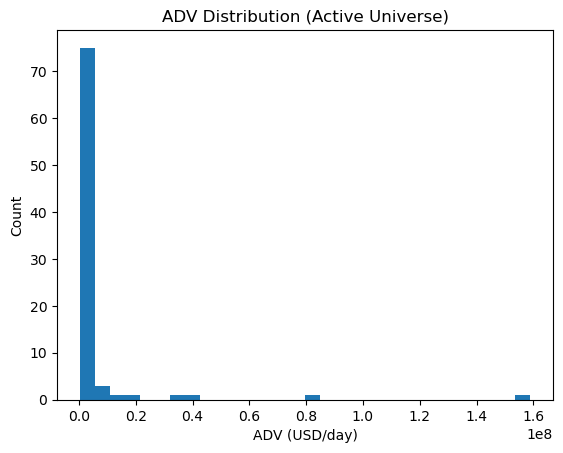

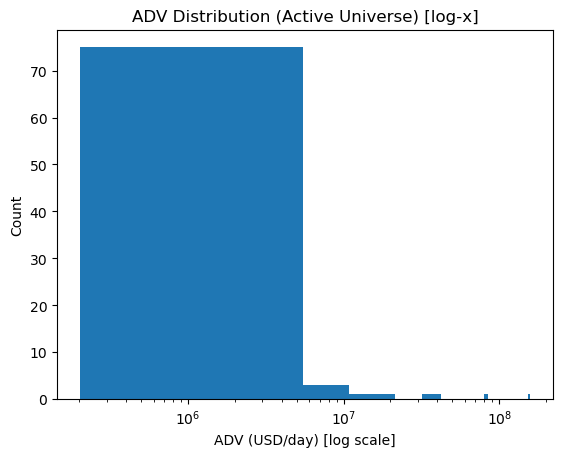


=== Concentration ===
Total ADV (active): 447,545,385 USD/day
Top 10 ADV: 377,085,210 USD/day
Top 10 share: 84.26%

Top 10 names:
      wsname      adv_usd
     XBT/USD 1.589754e+08
     ETH/USD 8.338298e+07
     SOL/USD 4.230568e+07
     XRP/USD 3.575284e+07
     ZEC/USD 1.668465e+07
     SUI/USD 1.257309e+07
     XMR/USD 8.570619e+06
     XDG/USD 7.351478e+06
     ADA/USD 6.633488e+06
FARTCOIN/USD 4.854958e+06


TypeError: Cannot localize tz-aware Timestamp, use tz_convert for conversions

In [420]:
results = run_universe_sanity_checks(
    panel_b=panel_b_fixed,
    panel_c=panel_c_fixed,
    eval_date="2026-02-01",
    do_spreads=True,  # start False to avoid Depth-related issues; turn on after it runs
    spread_days=3,        # start small
    spread_freq="2H",     # fewer calls
    spread_sleep_s=0.10   # slower; reduces failures
)